<a href="https://colab.research.google.com/github/ankaiahpallapu/IMDB_Movie_SentimentAnalysis_Using_DeepLearning/blob/main/IMDB_SentimentalAnalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 1. Import our tools
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

print("All tools imported successfully!")

All tools imported successfully!


In [ ]:
# 2. Load the IMDB dataset
num_words = 50000 # To make the data smaller and faster to train
(x_train, y_train), (x_test, y_test) = keras.datasets.imdb.load_data(num_words=num_words)

# 3. Print the shapes
print("Training data shape (reviews):", len(x_train))
print("Training data shape (labels):", len(y_train))
print("Test data shape (reviews):", len(x_test))
print("Test data shape (labels):", len(y_test))

print("\nFirst 5 training labels:", y_train[:5])

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data shape (reviews): 25000
Training data shape (labels): 25000
Test data shape (reviews): 25000
Test data shape (labels): 25000

First 5 training labels: [1 0 0 1 0]


In [ ]:
# 4. Look at the first review
print("First review (as numbers):")
print(x_train[0])
print("\nLength of first review:", len(x_train[0]))

First review (as numbers):
[1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 22665, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 21631, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 19193, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 10311, 8, 4, 107, 117, 5952, 15, 256, 4, 31050, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 12118, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 1334, 88, 12, 16, 283, 5, 16, 4472, 113, 103, 32, 15, 16, 5345, 19, 178, 32]

Length o

In [ ]:
# 5. Get the word index (the dictionary that maps words to numbers)
word_index = keras.datasets.imdb.get_word_index()

# 6. Reverse the dictionary (number → word)
reverse_word_index = {value: key for key, value in word_index.items()}

# 7. Function to decode a review
def decode_review(encoded_review):
    # The IMDB dataset uses offset 3 for special tokens
    return ' '.join([reverse_word_index.get(i - 3, '?') for i in encoded_review])

# 8. Decode and print the first review
print("First review (as words):")
print(decode_review(x_train[0]))

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
First review (as words):
? this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert redford's is an amazing actor and now the same being director norman's father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for retail and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also congratulations to the two little boy's that played the part's of norman and paul they were just brilliant children are often left out of the praising list i think because the stars that play them all grown up are such a b

In [ ]:
# 9. Pad the sequences to make them all the same length
maxlen = 500
x_train_padded = keras.preprocessing.sequence.pad_sequences(x_train, maxlen=maxlen)
x_test_padded = keras.preprocessing.sequence.pad_sequences(x_test, maxlen=maxlen)

print("Training data shape (padded):", x_train_padded.shape)  # (25000, 500)
print("Test data shape (padded):", x_test_padded.shape)       # (25000, 500)

# 10. Look at the first padded review
print("\nFirst review (padded, first 10 numbers):")
print(x_train_padded[0][:10])
print("\nFirst review (padded, last 10 numbers):")
print(x_train_padded[0][-10:])

Training data shape (padded): (25000, 500)
Test data shape (padded): (25000, 500)

First review (padded, first 10 numbers):
[0 0 0 0 0 0 0 0 0 0]

First review (padded, last 10 numbers):
[4472  113  103   32   15   16 5345   19  178   32]


In [ ]:
import tensorflow as tf

# 11. Build the Neural Network with Conv1D and GlobalMaxPooling1D
model = keras.Sequential([
    # Embedding Layer: Maps word indices to dense vectors
    keras.layers.Embedding(input_dim=num_words, output_dim=256),

    # Conv1D Layer: Extracts local features (n-grams) from the word embeddings.
    # It uses 128 filters, each with a kernel size of 5 (considering 5 consecutive words).
    keras.layers.Conv1D(filters=128, kernel_size=5, activation='relu'),

    # GlobalMaxPooling1D: Downsamples the feature maps by taking the maximum value
    # over the entire sequence. This captures the most salient features regardless of their position.
    keras.layers.GlobalMaxPooling1D(),

    # Dense Layer 1: Fully connected layer with 128 neurons and ReLU activation
    keras.layers.Dense(128, activation='relu'),

    # Dropout: Randomly sets 50% of input units to 0 at each update during training
    # to prevent overfitting.
    keras.layers.Dropout(0.5),

    # Dense Layer 2: Fully connected layer with 64 neurons and ReLU activation
    keras.layers.Dense(64, activation='relu'),

    # Dropout: Another dropout layer for regularization.
    keras.layers.Dropout(0.5),

    # Output Layer: Single neuron with Sigmoid activation for binary classification.
    # Outputs a probability score between 0 and 1.
    keras.layers.Dense(1, activation='sigmoid')
])

# 12. Print the model summary
model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
### Understanding the CNN Model Architecture and Data Processing

Let's break down each layer of our new Convolutional Neural Network (CNN) model and see how your movie review data is transformed at each step.

---

#### 1. Embedding Layer

*   **Purpose**: This is the first layer your text data encounters. Words, represented as numerical indices, are not directly useful for a neural network. The Embedding layer converts these sparse integer indices into dense, fixed-size vectors (embeddings) that capture semantic meaning. Words with similar meanings will have similar vectors.

*   **Input**: A sequence of word indices for each review. For a padded review of `maxlen=500` words, the input for one review is `(500,)` (a vector of 500 integers).

*   **Output**: Each word index is replaced by its corresponding embedding vector. If `output_dim=256`, each word becomes a 256-dimensional vector. So, a review of 500 words transforms into a `(500, 256)` tensor.

*   **Conceptual Visualization**:

    ```
    Input Review (word indices): [word_idx_1, word_idx_2, ..., word_idx_500]
    Shape: (500,)

          ↓

    Embedding Layer Output (word vectors):
    [[vec_1_dim1, vec_1_dim2, ..., vec_1_dim256],
     [vec_2_dim1, vec_2_dim2, ..., vec_2_dim256],
     ...,
     [vec_500_dim1, vec_500_dim2, ..., vec_500_dim256]]
    Shape: (500, 256)
    ```

---

#### 2. Conv1D Layer (Convolutional Layer for 1D Data)

*   **Purpose**: This layer is the core of the CNN. It's designed to detect local patterns (like n-grams or sequences of words) in the text. It slides a "filter" (or kernel) of a specific size across the sequence of word embeddings. Each filter specializes in detecting a particular feature.
    *   `filters=128`: We have 128 different filters, each learning to detect a distinct pattern.
    *   `kernel_size=5`: Each filter looks at 5 consecutive word embeddings at a time (e.g., a 5-gram).
    *   `activation='relu'`: Applies the Rectified Linear Unit activation function to introduce non-linearity.

*   **Input**: The 3D output from the Embedding layer `(batch_size, maxlen, embedding_dim)` which is `(None, 500, 256)` where `None` represents the batch size.

*   **Processing**: Each of the 128 filters slides over the `(500, 256)` input. For each position, it performs a dot product and sums the results, then applies the ReLU activation. Since the `kernel_size` is 5, the output sequence length will be `maxlen - kernel_size + 1 = 500 - 5 + 1 = 496`.

*   **Output**: A tensor representing the detected features. For each review, there will be 128 feature maps, each of length 496. So, the shape becomes `(None, 496, 128)`.

*   **Conceptual Visualization**:

    ```
    Input (Embedding Output): (500 words, 256 dimensions per word)

          ↓

    Conv1D Layer (128 filters, kernel size 5):
    Imagine 128 different "pattern detectors" scanning the word embeddings.
    Each detector looks at 5 words at a time and outputs a strength of detection.

    For each filter, you get a new sequence:
    [pattern_strength_1, pattern_strength_2, ..., pattern_strength_496] (for Filter 1)
    [pattern_strength_1, pattern_strength_2, ..., pattern_strength_496] (for Filter 2)
    ...
    [pattern_strength_1, pattern_strength_2, ..., pattern_strength_496] (for Filter 128)

    Output Shape: (496, 128) - meaning 496 positions, each with 128 detected features.
    ```

---

#### 3. GlobalMaxPooling1D Layer

*   **Purpose**: After the `Conv1D` layer has extracted features, we need to consolidate them. `GlobalMaxPooling1D` performs downsampling by taking the maximum value from each feature map across the entire sequence dimension. This means for each of the 128 filters, it finds the *most strongly activated feature* detected anywhere in the review. This layer is effective because the presence of a strong feature is often more important than its exact position.

*   **Input**: The output from the `Conv1D` layer `(None, 496, 128)`.

*   **Processing**: For each of the 128 feature maps (which are vectors of length 496), `GlobalMaxPooling1D` selects the single largest value.

*   **Output**: A single vector of length 128 for each review. Each element in this vector represents the strongest activation for one of the 128 features learned by the `Conv1D` filters. The shape becomes `(None, 128)`.

*   **Conceptual Visualization**:

    ```
    Input (Conv1D Output): (496 positions, 128 features)

          ↓

    GlobalMaxPooling1D:
    For each of the 128 features (columns), find the maximum value across all 496 positions (rows).

    Example (simplified):
    Feature 1 detections: [0.1, 0.8, 0.2, ..., 0.5]  -> max(0.8)
    Feature 2 detections: [0.3, 0.1, 0.9, ..., 0.2]  -> max(0.9)
    ...
    Feature 128 detections: [...]                 -> max(...)

    Output (single vector): [max_feature_1, max_feature_2, ..., max_feature_128]
    Shape: (128,)
    ```

---

#### 4. Dense Layers & Dropout

*   **Purpose**: These are standard fully connected layers that take the extracted and summarized features from the `GlobalMaxPooling1D` layer and learn more complex combinations of these features.
    *   `Dense(128, activation='relu')`: A layer with 128 neurons, applying ReLU activation.
    *   `Dropout(0.5)`: A regularization technique. During training, it randomly sets 50% of the neuron outputs to zero. This prevents neurons from becoming too reliant on specific inputs and helps the model generalize better to unseen data.
    *   `Dense(64, activation='relu')`: Another fully connected layer with 64 neurons, further processing the features.
    *   `Dropout(0.5)`: Another dropout layer for further regularization.

*   **Input**: The flattened feature vector from `GlobalMaxPooling1D`, which is `(None, 128)` for the first Dense layer.

*   **Output**: The output shape will be `(None, 128)` after the first Dense layer, then `(None, 64)` after the second Dense layer.

*   **Conceptual Visualization**:

    ```
    Input (GlobalMaxPooling1D Output): [max_feature_1, ..., max_feature_128]
    Shape: (128,)

          ↓

    Dense Layer 1 (128 neurons):
    Each input feature is connected to every neuron in this layer. The neurons activate based on weighted sums.
    Output: [hidden_feature_1, ..., hidden_feature_128]
    Shape: (128,)

          ↓

    Dropout (0.5):
    Randomly zeroes out 50% of the hidden features to prevent overfitting.
    Output: [hidden_feature'_1, 0.0, ..., hidden_feature'_128]
    Shape: (128,)

          ↓

    Dense Layer 2 (64 neurons):
    Further combines and transforms the features.
    Output: [more_abstract_feature_1, ..., more_abstract_feature_64]
    Shape: (64,)

          ↓

    Dropout (0.5):
    Another round of regularization.
    Output: [more_abstract_feature'_1, 0.0, ..., more_abstract_feature'_64]
    Shape: (64,)
    ```

---

#### 5. Output Layer

*   **Purpose**: This is the final layer that produces the sentiment prediction.
    *   `Dense(1, activation='sigmoid')`: A single neuron with a sigmoid activation function. The sigmoid function squashes its input into a value between 0 and 1, which can be interpreted as a probability.

*   **Input**: The processed features from the last Dropout layer `(None, 64)`.

*   **Output**: A single probability score between 0 and 1 for each review. A score closer to 1 indicates a positive sentiment, while a score closer to 0 indicates a negative sentiment. The shape is `(None, 1)`.

*   **Conceptual Visualization**:

    ```
    Input (Last Dropout Output): [abstract_feature'_1, ..., abstract_feature'_64]
    Shape: (64,)

          ↓

    Output Layer (1 neuron, sigmoid activation):
    All 64 abstract features are fed into a single neuron.
    This neuron calculates a weighted sum and applies the sigmoid function.

    Output: [probability_of_positive_sentiment]
    Shape: (1,)
    ```

---

This CNN architecture leverages convolutional layers to automatically learn salient patterns in your text data, followed by pooling to summarize these patterns, and finally, dense layers to classify the sentiment based on these learned features. The dropout layers help in preventing the model from memorizing the training data, leading to better generalization.

### Understanding the CNN Model Architecture and Data Processing

Let's break down each layer of our new Convolutional Neural Network (CNN) model and see how your movie review data is transformed at each step.

---

#### 1. Embedding Layer

*   **Purpose**: This is the first layer your text data encounters. Words, represented as numerical indices, are not directly useful for a neural network. The Embedding layer converts these sparse integer indices into dense, fixed-size vectors (embeddings) that capture semantic meaning. Words with similar meanings will have similar vectors.

*   **Input**: A sequence of word indices for each review. For a padded review of `maxlen=500` words, the input for one review is `(500,)` (a vector of 500 integers).

*   **Output**: Each word index is replaced by its corresponding embedding vector. If `output_dim=256`, each word becomes a 256-dimensional vector. So, a review of 500 words transforms into a `(500, 256)` tensor.

*   **Conceptual Visualization**:

    ```
    Input Review (word indices): [word_idx_1, word_idx_2, ..., word_idx_500]
    Shape: (500,)

          ↓

    Embedding Layer Output (word vectors):
    [[vec_1_dim1, vec_1_dim2, ..., vec_1_dim256],
     [vec_2_dim1, vec_2_dim2, ..., vec_2_dim256],
     ...,
     [vec_500_dim1, vec_500_dim2, ..., vec_500_dim256]]
    Shape: (500, 256)
    ```

---

#### 2. Conv1D Layer (Convolutional Layer for 1D Data)

*   **Purpose**: This layer is the core of the CNN. It's designed to detect local patterns (like n-grams or sequences of words) in the text. It slides a "filter" (or kernel) of a specific size across the sequence of word embeddings. Each filter specializes in detecting a particular feature.
    *   `filters=128`: We have 128 different filters, each learning to detect a distinct pattern.
    *   `kernel_size=5`: Each filter looks at 5 consecutive word embeddings at a time (e.g., a 5-gram).
    *   `activation='relu'`: Applies the Rectified Linear Unit activation function to introduce non-linearity.

*   **Input**: The 3D output from the Embedding layer `(batch_size, maxlen, embedding_dim)` which is `(None, 500, 256)` where `None` represents the batch size.

*   **Processing**: Each of the 128 filters slides over the `(500, 256)` input. For each position, it performs a dot product and sums the results, then applies the ReLU activation. Since the `kernel_size` is 5, the output sequence length will be `maxlen - kernel_size + 1 = 500 - 5 + 1 = 496`.

*   **Output**: A tensor representing the detected features. For each review, there will be 128 feature maps, each of length 496. So, the shape becomes `(None, 496, 128)`.

*   **Conceptual Visualization**:

    ```
    Input (Embedding Output): (500 words, 256 dimensions per word)
    
          ↓

    Conv1D Layer (128 filters, kernel size 5):
    Imagine 128 different "pattern detectors" scanning the word embeddings.
    Each detector looks at 5 words at a time and outputs a strength of detection.

    For each filter, you get a new sequence:
    [pattern_strength_1, pattern_strength_2, ..., pattern_strength_496] (for Filter 1)
    [pattern_strength_1, pattern_strength_2, ..., pattern_strength_496] (for Filter 2)
    ...
    [pattern_strength_1, pattern_strength_2, ..., pattern_strength_496] (for Filter 128)

    Output Shape: (496, 128) - meaning 496 positions, each with 128 detected features.
    ```

---

#### 3. GlobalMaxPooling1D Layer

*   **Purpose**: After the `Conv1D` layer has extracted features, we need to consolidate them. `GlobalMaxPooling1D` performs downsampling by taking the maximum value from each feature map across the entire sequence dimension. This means for each of the 128 filters, it finds the *most strongly activated feature* detected anywhere in the review. This layer is effective because the presence of a strong feature is often more important than its exact position.

*   **Input**: The output from the `Conv1D` layer `(None, 496, 128)`.

*   **Processing**: For each of the 128 feature maps (which are vectors of length 496), `GlobalMaxPooling1D` selects the single largest value.

*   **Output**: A single vector of length 128 for each review. Each element in this vector represents the strongest activation for one of the 128 features learned by the `Conv1D` filters. The shape becomes `(None, 128)`.

*   **Conceptual Visualization**:

    ```
    Input (Conv1D Output): (496 positions, 128 features)
    
          ↓

    GlobalMaxPooling1D:
    For each of the 128 features (columns), find the maximum value across all 496 positions (rows).

    Example (simplified):
    Feature 1 detections: [0.1, 0.8, 0.2, ..., 0.5]  -> max(0.8)
    Feature 2 detections: [0.3, 0.1, 0.9, ..., 0.2]  -> max(0.9)
    ...
    Feature 128 detections: [...]                 -> max(...)

    Output (single vector): [max_feature_1, max_feature_2, ..., max_feature_128]
    Shape: (128,)
    ```

---

#### 4. Dense Layers & Dropout

*   **Purpose**: These are standard fully connected layers that take the extracted and summarized features from the `GlobalMaxPooling1D` layer and learn more complex combinations of these features.
    *   `Dense(128, activation='relu')`: A layer with 128 neurons, applying ReLU activation.
    *   `Dropout(0.5)`: A regularization technique. During training, it randomly sets 50% of the neuron outputs to zero. This prevents neurons from becoming too reliant on specific inputs and helps the model generalize better to unseen data.
    *   `Dense(64, activation='relu')`: Another fully connected layer with 64 neurons, further processing the features.
    *   `Dropout(0.5)`: Another dropout layer for further regularization.

*   **Input**: The flattened feature vector from `GlobalMaxPooling1D`, which is `(None, 128)` for the first Dense layer.

*   **Output**: The output shape will be `(None, 128)` after the first Dense layer, then `(None, 64)` after the second Dense layer.

*   **Conceptual Visualization**:

    ```
    Input (GlobalMaxPooling1D Output): [max_feature_1, ..., max_feature_128]
    Shape: (128,)

          ↓

    Dense Layer 1 (128 neurons):
    Each input feature is connected to every neuron in this layer. The neurons activate based on weighted sums.
    Output: [hidden_feature_1, ..., hidden_feature_128]
    Shape: (128,)

          ↓

    Dropout (0.5):
    Randomly zeroes out 50% of the hidden features to prevent overfitting.
    Output: [hidden_feature'_1, 0.0, ..., hidden_feature'_128]
    Shape: (128,)

          ↓

    Dense Layer 2 (64 neurons):
    Further combines and transforms the features.
    Output: [more_abstract_feature_1, ..., more_abstract_feature_64]
    Shape: (64,)

          ↓

    Dropout (0.5):
    Another round of regularization.
    Output: [more_abstract_feature'_1, 0.0, ..., more_abstract_feature'_64]
    Shape: (64,)
    ```

---

#### 5. Output Layer

*   **Purpose**: This is the final layer that produces the sentiment prediction.
    *   `Dense(1, activation='sigmoid')`: A single neuron with a sigmoid activation function. The sigmoid function squashes its input into a value between 0 and 1, which can be interpreted as a probability.

*   **Input**: The processed features from the last Dropout layer `(None, 64)`.

*   **Output**: A single probability score between 0 and 1 for each review. A score closer to 1 indicates a positive sentiment, while a score closer to 0 indicates a negative sentiment. The shape is `(None, 1)`.

*   **Conceptual Visualization**:

    ```
    Input (Last Dropout Output): [abstract_feature'_1, ..., abstract_feature'_64]
    Shape: (64,)

          ↓

    Output Layer (1 neuron, sigmoid activation):
    All 64 abstract features are fed into a single neuron.
    This neuron calculates a weighted sum and applies the sigmoid function.

    Output: [probability_of_positive_sentiment]
    Shape: (1,)
    ```

---

This CNN architecture leverages convolutional layers to automatically learn salient patterns in your text data, followed by pooling to summarize these patterns, and finally, dense layers to classify the sentiment based on these learned features. The dropout layers help in preventing the model from memorizing the training data, leading to better generalization.

In [ ]:
# 13. Compile the model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully!")

Model compiled successfully!


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

# Define EarlyStopping callback
early_stopping = EarlyStopping(
    monitor='val_loss', # Monitor validation loss
    patience=3,         # Number of epochs with no improvement after which training will be stopped
    restore_best_weights=True # Restore model weights from the epoch with the best value of the monitored quantity.
)

# 14. Train the model
history = model.fit(
    x_train_padded,      # Training reviews (padded)
    y_train,             # Training labels (0 or 1)
    epochs=20,           # Increase epochs, EarlyStopping will manage when to stop
    batch_size=128,      # Number of reviews to process at once
    validation_split=0.2, # Use 20% of training data for validation
    callbacks=[early_stopping] # Add the EarlyStopping callback
)

print("\nTraining completed!")

Epoch 1/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 294s 2s/step - accuracy: 0.6676 - loss: 0.5769 - val_accuracy: 0.8566 - val_loss: 0.3414
Epoch 2/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 292s 2s/step - accuracy: 0.9094 - loss: 0.2401 - val_accuracy: 0.8972 - val_loss: 0.2567
Epoch 3/20
135/157 ━━━━━━━━━━━━━━━━━━━━ 39s 2s/step - accuracy: 0.9823 - loss: 0.0629

KeyboardInterrupt: 

In [ ]:
# 15. Evaluate the model on the test set
test_loss, test_accuracy = model.evaluate(x_test_padded, y_test)

print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.8120 - loss: 0.4357

Test Loss: 0.4357
Test Accuracy: 81.20%


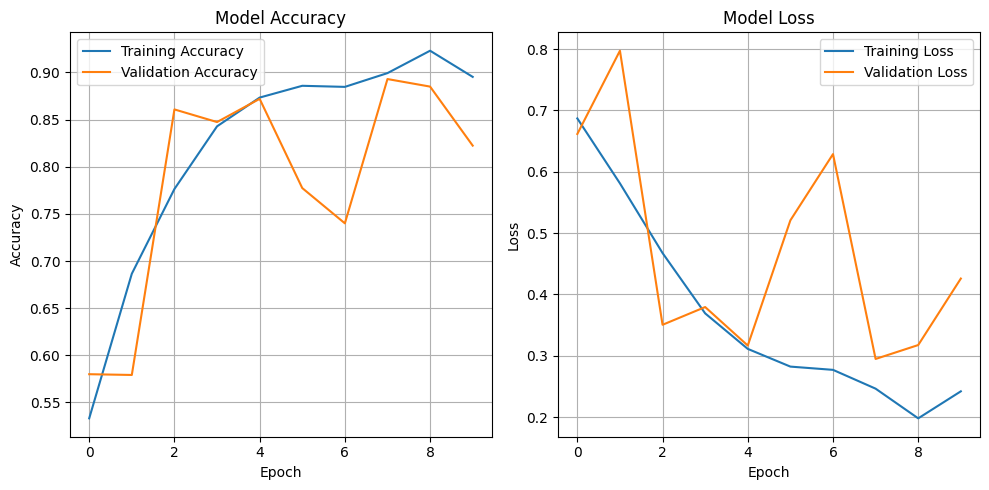

In [ ]:
# 16. Plot training history
plt.figure(figsize=(10, 5))

# Plot training & validation accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plot training & validation loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# 17. Function to convert text to numbers
def text_to_numbers(text):
    # Get the word index
    word_index = keras.datasets.imdb.get_word_index()

    # Convert text to lowercase and split into words
    words = text.lower().split()

    # Convert each word to its number (if it exists in the vocabulary)
    # The IMDB dataset uses offset 3
    numbers = []
    for word in words:
        if word in word_index:
            # Add 3 because of IMDB offset
            numbers.append(word_index[word] + 3)
        else:
            # Unknown word
            numbers.append(2)  # 2 is the code for unknown

    return numbers

# 18. Function to predict sentiment
def predict_sentiment(text):
    # Convert text to numbers
    numbers = text_to_numbers(text)

    # Pad the sequence
    padded = keras.preprocessing.sequence.pad_sequences([numbers], maxlen=maxlen)

    # Make prediction
    prediction = model.predict(padded)[0][0]

    # Return sentiment
    if prediction > 0.5:
        return f"Positive (confidence: {prediction * 100:.2f}%)"
    else:
        return f"Negative (confidence: {(1 - prediction) * 100:.2f}%)"

In [ ]:
# 19. Test with custom reviews
print("--- TESTING WITH CUSTOM REVIEWS ---\n")

review1 = "This movie was amazing! The acting was excellent and the story was fantastic."
print(f"Review 1: {review1}")
print(f"Sentiment: {predict_sentiment(review1)}\n")

review2 = "The movie was too slow, the characters were uninteresting, and I didn't enjoy it at all."
print(f"Review 2: {review2}")
print(f"Sentiment: {predict_sentiment(review2)}\n")

review3 = "The film was okay. Some parts were good, some parts were boring. I'm not sure if I would recommend it."
print(f"Review 3: {review3}")
print(f"Sentiment: {predict_sentiment(review3)}\n")

--- TESTING WITH CUSTOM REVIEWS ---

Review 1: This movie was amazing! The acting was excellent and the story was fantastic.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
Sentiment: Positive (confidence: 91.50%)

Review 2: The movie was too slow, the characters were uninteresting, and I didn't enjoy it at all.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Sentiment: Positive (confidence: 88.94%)

Review 3: The film was okay. Some parts were good, some parts were boring. I'm not sure if I would recommend it.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Sentiment: Positive (confidence: 85.36%)



In [ ]:
# 20. Test with your own review
my_review = input("Write a movie review: ")
print(f"\nYour review: {my_review}")
print(f"Sentiment: {predict_sentiment(my_review)}")

Write a movie review:  The movie was too slow, the characters were uninteresting, and I didn't enjoy it at all.

Your review:  The movie was too slow, the characters were uninteresting, and I didn't enjoy it at all.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Sentiment: Positive (confidence: 88.94%)
